# Single models

## Setup

In [1]:
import os

In [2]:
import numpy as np
import pandas as pd
import geopandas as gpd

In [3]:
import xarray as xr
import rioxarray as rxr

In [4]:
import rasterio

In [5]:
from imblearn.over_sampling import RandomOverSampler

In [6]:
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.model_selection import GroupShuffleSplit, StratifiedGroupKFold
from sklearn.metrics import classification_report, confusion_matrix, precision_recall_curve 

In [7]:
from sklearn import metrics

In [8]:
from sklearn.inspection import PartialDependenceDisplay

In [9]:
import xgboost as xgb

In [10]:
import matplotlib.pyplot as plt

In [11]:
import matplotlib.cm as cm
import matplotlib.colors as colors

In [12]:
import sys
sys.path.insert(0, os.path.abspath('../scripts'))

In [13]:
from data_utils import xarray_pred_all_to_tif

In [14]:
DATA_DIR = '../data'

In [15]:
FIGURES_DIR = '../saved_figures'

## Load sampled data

In [16]:
samples_df = pd.read_csv(os.path.join(DATA_DIR, 'samples_v5.csv'))

In [17]:
samples_df = samples_df.drop(columns=['Unnamed: 0'])

In [18]:
samples_df.head()

,points,latitude,longitude,bitmask,Rnir,Rgli,logchl,logfb,Rw443,Rw490,...,Substrate,PercGravel,PercMud,PercSand,Presence,y,x,spatial_ref,tileId,tile_grid
0,13.0,55.222114,-6.630028,0.0,0.030331,0.001693,-0.094078,0.472445,0.021205,0.022442,...,4.0,16.742907,10.777808,72.61467,1.0,6122070.0,650750.0,0.0,29UPB,29UPB20
1,10.0,55.222555,-6.624970,0.0,0.030231,0.001702,0.072536,0.506929,0.018965,0.021337,...,4.0,15.857829,11.206201,73.08904,1.0,6122130.0,651070.0,0.0,29UPB,29UPB20
2,11.0,55.222510,-6.631891,0.0,0.031733,0.001689,0.220050,0.449105,0.013924,0.017181,...,4.0,17.361425,10.430368,72.32388,1.0,6122110.0,650630.0,0.0,29UPB,29UPB20
3,13.0,55.222114,-6.630028,0.0,0.030331,0.001693,-0.094078,0.472445,0.021205,0.022442,...,4.0,16.742907,10.777808,72.61467,1.0,6122070.0,650750.0,0.0,29UPB,29UPB20
4,9.0,55.222561,-6.625284,0.0,0.029630,0.001701,0.002956,0.515390,0.020957,0.022635,...,4.0,15.817097,11.216836,73.14491,1.0,6122130.0,651050.0,0.0,29UPB,29UPB20


In [19]:
samples_df = samples_df.dropna()

In [20]:
samples_df['Presence'].value_counts()

Presence
0.0    7951
1.0    2670
Name: count, dtype: int64

In [21]:
np.array(samples_df['tile_grid'][samples_df['Presence'] == 1.0].value_counts()).mean()

np.float64(30.0)

In [22]:
np.array(samples_df['tile_grid'][samples_df['Presence'] == 0.0].value_counts()).mean()

np.float64(7.943056943056943)

## Load data tiles

In [23]:
def tileId_to_epsg(tileId):
    zone = int(tileId[:2])
    return f'EPSG:326{zone}'

In [24]:
data_tiles_all = {}
data_tiles_dir = os.path.join(DATA_DIR, 'data_tiles')
for f in os.listdir(data_tiles_dir):
    if not f.startswith('data_tile'):
        continue

    tile_id = f[10:15]

    f_full = os.path.join(data_tiles_dir, f)
    
    ds = xr.open_dataset(f_full, chunks={})

    if 'PercGravel' not in ds.data_vars:
        ds.close()
        continue
    
    data_tiles_all[tile_id] = ds
    data_tiles_all[tile_id].chunk({'y': 2048, 'x': 2048})
    tile_crs = tileId_to_epsg(tile_id)
    data_tiles_all[tile_id].rio.write_crs(tile_crs, inplace=True)

## Models

### Data setup

In [25]:
samples_df.columns

Index(['points', 'latitude', 'longitude', 'bitmask', 'Rnir', 'Rgli', 'logchl',
       'logfb', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'Rw705', 'Rw740', 'Rw783',
       'Rw842', 'Rw865', 'Rw1610', 'bathymetry', 'SurveyKDE', 'ZM_Gauss',
       'grid_id', 'WavesKE', 'Substrate', 'PercGravel', 'PercMud', 'PercSand',
       'Presence', 'y', 'x', 'spatial_ref', 'tileId', 'tile_grid'],
      dtype='object')

In [26]:
samples_df['NDTI'] = (samples_df['Rw665'] - samples_df['Rw560']) / (samples_df['Rw665'] + samples_df['Rw560'])

In [27]:
predictors = ['Rnir', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'logchl', 'bathymetry', 'WavesKE', 'PercGravel', 'PercMud', 'PercSand', 'NDTI']

In [28]:
groups = samples_df['tile_grid']

In [29]:
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)

In [30]:
for train_idx, test_idx in gss.split(samples_df, groups=groups):
    train_data = samples_df.iloc[train_idx]
    test_data = samples_df.iloc[test_idx]
    break

    # if n_splits > 1, continue in for loop

In [31]:
X_train = train_data[predictors]
X_test = test_data[predictors]
y_train = train_data['Presence']
y_test = test_data['Presence']

In [32]:
train_data['tile_grid'].unique()

array(['29UPB20', '29UPB30', '29UPB34', '29UPB0', '29UPB4', '29UPB5',
       '29UPB7', '29UPB8', '29UPB9', '29UPB10', '29UPB12', '29UPB13',
       '29UPB14', '29UPB16', '29UPB17', '29UPB18', '29UPB19', '29UPB23',
       '29UPB24', '29UPB25', '29UPB28', '29UPB29', '29UPB31', '29UPB33',
       '29UPB36', '29UPB37', '29UPB38', '29UPB42', '29UPB43', '29UPB45',
       '29UPB48', '29UPB51', '29UPB52', '29UPB58', '29UPB59', '29UPB64',
       '29UPB65', '29UPB67', '29UPB68', '29UPB69', '29UPR2', '29UPR5',
       '29UPR0', '29UPR1', '29UPR4', '29UPR6', '29VPC19', '29VPC41',
       '29VPC57', '29VPC0', '29VPC6', '29VPC7', '29VPC8', '29VPC9',
       '29VPC11', '29VPC12', '29VPC14', '29VPC18', '29VPC21', '29VPC24',
       '29VPC28', '29VPC29', '29VPC30', '29VPC32', '29VPC36', '29VPC37',
       '29VPC39', '29VPC42', '29VPC43', '29VPC44', '29VPC45', '29VPC46',
       '29VPC48', '29VPC50', '29VPC54', '29VPC55', '29VPC56', '29VPC58',
       '29VPC61', '29VPC63', '29VPC64', '29VPC65', '29VPC66', '29VPC

In [33]:
test_data['tile_grid'].unique()

array(['29UPB41', '29UPB22', '29UPB39', '29UPB46', '29UPB47', '29UPB66',
       '29UPB70', '29VPC1', '29VPC3', '29VPC4', '29VPC10', '29VPC16',
       '29VPC17', '29VPC20', '29VPC25', '29VPC26', '29VPC31', '29VPC38',
       '29VPC49', '29VPC53', '29VPC62', '29VPC67', '29VPC74', '29VPC77',
       '29VPE0', '29VPE30', '29VPE31', '29VPE33', '29VPE56', '29VPE79',
       '29VPE84', '30UUA5', '30UUA6', '30UUA7', '30UUA15', '30UUA32',
       '30UUA33', '30UUB0', '30UUB12', '30UUB18', '30UUB20', '30UUC8',
       '30UUC7', '30UUC9', '30UUC15', '30UUC17', '30UUC26', '30UUC29',
       '30UUC37', '30UUC39', '30UUD5', '30UUD9', '30UUD11', '30UUE6',
       '30UUE8', '30UUE11', '30UUE16', '30UUE30', '30UUF0', '30UUF9',
       '30UUF11', '30UUF13', '30UUF22', '30UUF24', '30UUF26', '30UUF28',
       '30UUF30', '30UUF35', '30UUF39', '30UUF43', '30UUF51', '30UUF52',
       '30UUF59', '30UUF73', '30UUG4', '30UUG28', '30UUG30', '30UUG32',
       '30UUG39', '30UUG47', '30UUG51', '30UUG85', '30UUG89', '30UUG1

In [34]:
# np.save(os.path.join(DATA_DIR, 'tg_train'), train_data['tile_grid'].unique())
# np.save(os.path.join(DATA_DIR, 'tg_test'), test_data['tile_grid'].unique())

### Random Forest

In [35]:
model = RandomForestClassifier(
    n_estimators=100,
    max_depth=None,
    random_state=42,
    n_jobs=1,
    class_weight='balanced'
)

In [36]:
model.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', n_jobs=1, random_state=42)

In [37]:
model.feature_importances_

array([0.08753451, 0.07542085, 0.07525479, 0.11372913, 0.06261497,
       0.06011147, 0.14763042, 0.06368314, 0.07345064, 0.10244201,
       0.07689624, 0.06123183])

In [38]:
model.feature_names_in_

array(['Rnir', 'Rw443', 'Rw490', 'Rw560', 'Rw665', 'logchl', 'bathymetry',
       'WavesKE', 'PercGravel', 'PercMud', 'PercSand', 'NDTI'],
      dtype=object)

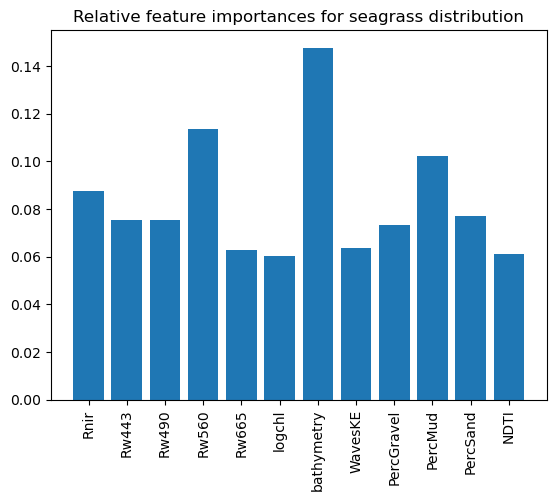

In [39]:
plt.bar(model.feature_names_in_, model.feature_importances_)
plt.xticks(rotation=90)
plt.title('Relative feature importances for seagrass distribution')
plt.savefig(os.path.join(FIGURES_DIR, 'feat_imp'), dpi=300, bbox_inches='tight')

In [40]:
y_pred = model.predict(X_test)

In [41]:
y_pred_proba = model.predict_proba(X_test)[:,1]

In [42]:
confusion_matrix(y_test, y_pred)

array([[1574,   13],
       [ 298,   62]])

In [43]:
print(classification_report(y_test, y_pred, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.84      0.99      0.91      1587
         1.0       0.83      0.17      0.29       360

    accuracy                           0.84      1947
   macro avg       0.83      0.58      0.60      1947
weighted avg       0.84      0.84      0.79      1947



**Precision-recall curve**

In [44]:
precision, recall, thresholds = precision_recall_curve(y_test, y_pred_proba)

In [45]:
# Find the threshold that gives the best F1-score
f1_scores = 2 * (precision * recall) / (precision + recall)
nan_idx = np.isnan(f1_scores)
f1_scores[nan_idx] = 0.0
best_threshold_index = np.argmax(f1_scores)
best_threshold = thresholds[best_threshold_index]
best_f1 = f1_scores[best_threshold_index]
print(f"Best Threshold: {best_threshold:.2f}")
print(f"Best F1-score: {best_f1:.2f}")

Best Threshold: 0.18
Best F1-score: 0.60


C:\Users\olley\AppData\Local\Temp\ipykernel_23384\1582379690.py:2: RuntimeWarning: invalid value encountered in divide
  f1_scores = 2 * (precision * recall) / (precision + recall)


In [46]:
precision[nan_idx] = np.nan
recall[nan_idx] = np.nan

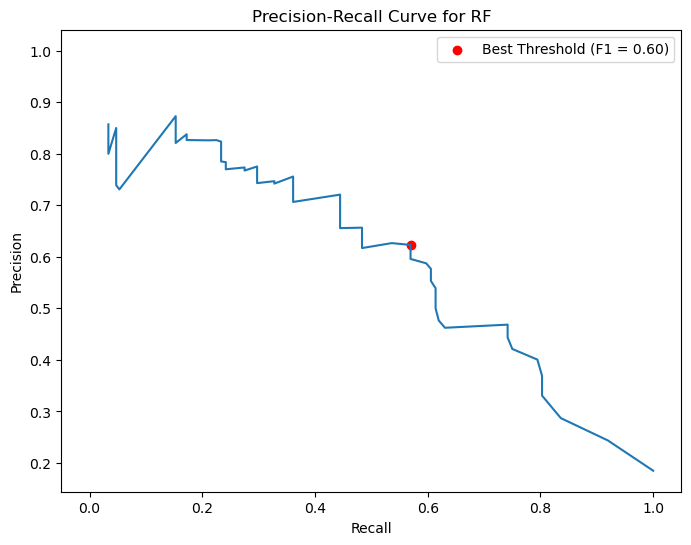

In [47]:
fig, ax = plt.subplots(figsize=(8,6))
ax.plot(recall, precision)
ax.set_xlabel('Recall')
ax.set_ylabel('Precision')
plt.title('Precision-Recall Curve for RF')

ax.scatter(recall[best_threshold_index], precision[best_threshold_index], color='red', label=f'Best Threshold (F1 = {best_f1:.2f})')
plt.legend(loc='best')
plt.savefig(os.path.join(FIGURES_DIR, 'pr_curve'), dpi=300)

In [48]:
y_pred_best = y_pred_proba.copy()
y_pred_best[y_pred_proba < best_threshold] = 0.0
y_pred_best[y_pred_proba >= best_threshold] = 1.0

In [49]:
confusion_matrix(y_test, y_pred_best)

array([[1463,  124],
       [ 155,  205]])

In [50]:
print(classification_report(y_test, y_pred_best, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.90      0.92      0.91      1587
         1.0       0.62      0.57      0.60       360

    accuracy                           0.86      1947
   macro avg       0.76      0.75      0.75      1947
weighted avg       0.85      0.86      0.85      1947



**ROC curve**

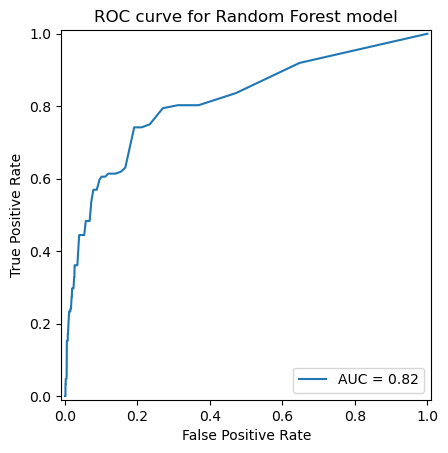

In [51]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()
plt.title('ROC curve for Random Forest model')
plt.savefig(os.path.join(FIGURES_DIR, 'roc_curve'), dpi=300)

**Partial dependence plots**

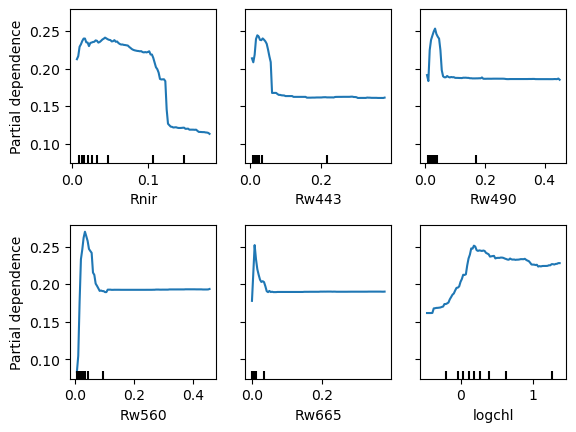

In [52]:
PartialDependenceDisplay.from_estimator(model, X_train, features=predictors[:6])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep1'), dpi=300)

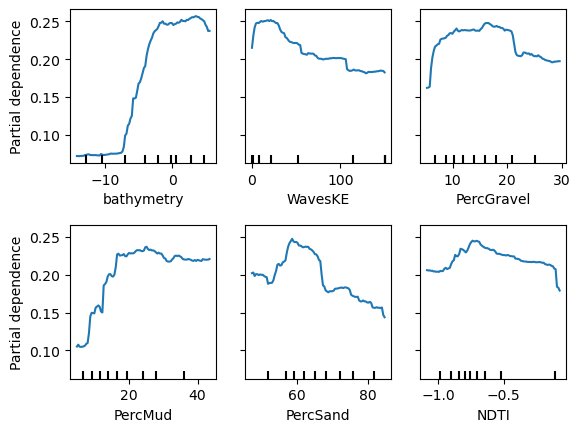

In [53]:
PartialDependenceDisplay.from_estimator(model, X_train, features=predictors[6:])
plt.subplots_adjust(hspace=0.4)
plt.savefig(os.path.join(FIGURES_DIR, 'part_dep2'), dpi=300)

### XGBoost

In [61]:
bst = xgb.XGBClassifier(objective="binary:logistic")
bst.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              gamma=None, grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, random_state=None, ...)

In [62]:
y_pred_bst = bst.predict(X_test)
y_pred_proba_bst = bst.predict_proba(X_test)[:,1]

In [63]:
print(classification_report(y_test, y_pred_bst, zero_division=0))

              precision    recall  f1-score   support

         0.0       0.74      0.99      0.85      1604
         1.0       0.83      0.13      0.22       630

    accuracy                           0.75      2234
   macro avg       0.79      0.56      0.53      2234
weighted avg       0.77      0.75      0.67      2234



**ROC curve**

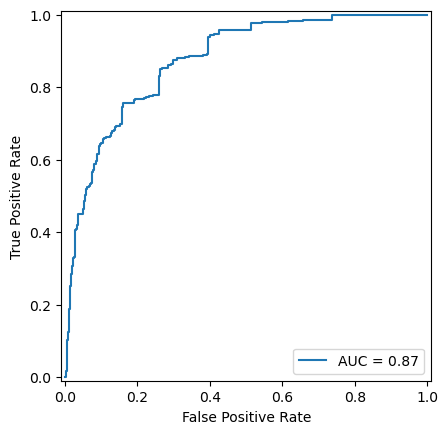

In [64]:
fpr, tpr, thresholds = metrics.roc_curve(y_test, y_pred_proba_bst)
roc_auc = metrics.auc(fpr, tpr)
display = metrics.RocCurveDisplay(fpr=fpr, tpr=tpr, roc_auc=roc_auc)
display.plot()

**Partial dependence plots**

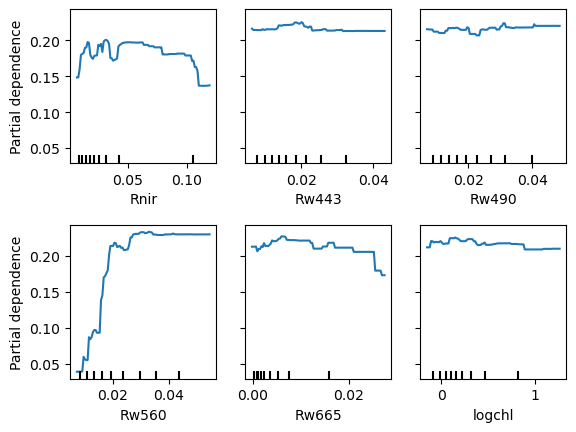

In [65]:
PartialDependenceDisplay.from_estimator(bst, X_train, features=predictors[:6])
plt.subplots_adjust(hspace=0.4)

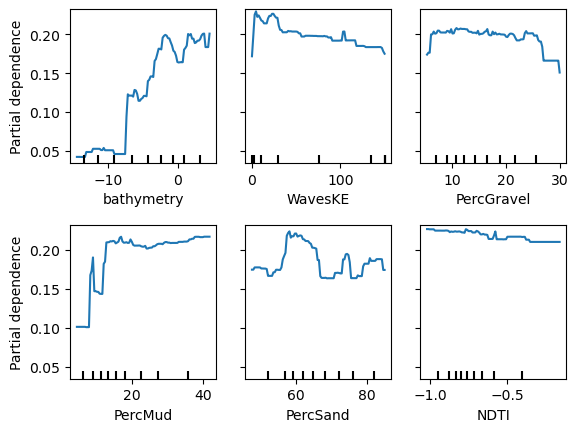

In [66]:
PartialDependenceDisplay.from_estimator(bst, X_train, features=predictors[6:])
plt.subplots_adjust(hspace=0.4)

## Prediction

### To TIFF

In [67]:
for tileId, ds in data_tiles_all.items():
    ds['bathymask'] = (ds['bathymetry'] > -15.0) & (ds['grid_id'] != 0.0) & (~np.isnan(ds['Rw490']))
    ds['NDTI'] = (ds['Rw665'] - ds['Rw560']) / (ds['Rw665'] + ds['Rw560'])

In [68]:
pred_dir = os.path.join(DATA_DIR, 'predictions')

In [70]:
rf_dir = os.path.join(pred_dir, 'rf_final')
tile_to_file = xarray_pred_all_to_tif(data_tiles_all, model, predictors, rf_dir, mask_band='bathymask')

Predicting for 29UPB...
Saved GeoTIFF: ../data\predictions\rf_final\29UPB_pred.tif
Prediction completed for 29UPB
Predicting for 29UPR...
Saved GeoTIFF: ../data\predictions\rf_final\29UPR_pred.tif
Prediction completed for 29UPR
Predicting for 29VPC...
Saved GeoTIFF: ../data\predictions\rf_final\29VPC_pred.tif
Prediction completed for 29VPC
Predicting for 29VPE...
Saved GeoTIFF: ../data\predictions\rf_final\29VPE_pred.tif
Prediction completed for 29VPE
Predicting for 30UUA...
Saved GeoTIFF: ../data\predictions\rf_final\30UUA_pred.tif
Prediction completed for 30UUA
Predicting for 30UUB...
Saved GeoTIFF: ../data\predictions\rf_final\30UUB_pred.tif
Prediction completed for 30UUB
Predicting for 30UUC...
Saved GeoTIFF: ../data\predictions\rf_final\30UUC_pred.tif
Prediction completed for 30UUC
Predicting for 30UUD...
Saved GeoTIFF: ../data\predictions\rf_final\30UUD_pred.tif
Prediction completed for 30UUD
Predicting for 30UUE...
Saved GeoTIFF: ../data\predictions\rf_final\30UUE_pred.tif
Predi

In [71]:
xgb_dir = os.path.join(pred_dir, 'xgb_final')
tile_to_file = xarray_pred_all_to_tif(data_tiles_all, bst, predictors, xgb_dir, mask_band='bathymask')

Predicting for 29UPB...
Saved GeoTIFF: ../data\predictions\xgb_final\29UPB_pred.tif
Prediction completed for 29UPB
Predicting for 29UPR...
Saved GeoTIFF: ../data\predictions\xgb_final\29UPR_pred.tif
Prediction completed for 29UPR
Predicting for 29VPC...
Saved GeoTIFF: ../data\predictions\xgb_final\29VPC_pred.tif
Prediction completed for 29VPC
Predicting for 29VPE...
Saved GeoTIFF: ../data\predictions\xgb_final\29VPE_pred.tif
Prediction completed for 29VPE
Predicting for 30UUA...
Saved GeoTIFF: ../data\predictions\xgb_final\30UUA_pred.tif
Prediction completed for 30UUA
Predicting for 30UUB...
Saved GeoTIFF: ../data\predictions\xgb_final\30UUB_pred.tif
Prediction completed for 30UUB
Predicting for 30UUC...
Saved GeoTIFF: ../data\predictions\xgb_final\30UUC_pred.tif
Prediction completed for 30UUC
Predicting for 30UUD...
Saved GeoTIFF: ../data\predictions\xgb_final\30UUD_pred.tif
Prediction completed for 30UUD
Predicting for 30UUE...
Saved GeoTIFF: ../data\predictions\xgb_final\30UUE_pred.